*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python
/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


Google Earth Engine berhasil diinisialisasi.
Batas wilayah DIY berhasil dimuat.
Komposit NTL 2025 berhasil dibuat.

HASIL EKSTRAKSI NTL 2025

Malioboro-Keraton                NTL = 37.376
Kawasan Industri Sentolo         NTL = 1.161
Kotagede                         NTL = 12.631
TN Gunung Merapi                 NTL = 0.959
Pantai Baron                     NTL = 1.692

Batas peta:
West  : 110.0036106034147
East  : 110.83463097770034
South : -8.205347946317348
North : -7.541896095120472

Citra NTL berhasil diambil dari GEE.


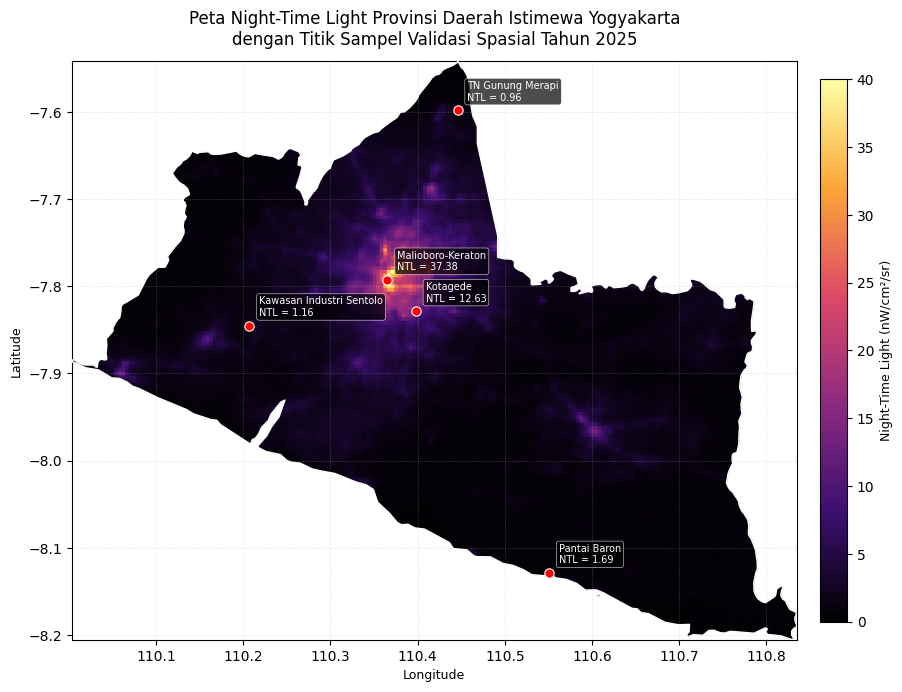


Peta berhasil disimpan sebagai: Gambar_Validasi_Spasial_NTL_DIY_2025.png


In [1]:
# ============================================================
# VALIDASI SPASIAL NTL DIY 2025
# PETA BERANOTASI - GOOGLE COLAB
# ============================================================

# Install library
!pip install earthengine-api -q

# ============================================================
# 0. IMPORT LIBRARY
# ============================================================

import ee
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from io import BytesIO


# ============================================================
# 1. AUTENTIKASI GOOGLE EARTH ENGINE
# ============================================================

ee.Authenticate()

ee.Initialize(
    project='hackaton-475107'
)

print("Google Earth Engine berhasil diinisialisasi.")


# ============================================================
# 2. BATAS WILAYAH DIY
# ============================================================

gaul = ee.FeatureCollection(
    "FAO/GAUL/2015/level1"
)

diy = gaul.filter(
    ee.Filter.And(
        ee.Filter.eq(
            'ADM0_NAME',
            'Indonesia'
        ),
        ee.Filter.eq(
            'ADM1_NAME',
            'Daerah Istimewa Yogyakarta'
        )
    )
)

region = diy.geometry()

print("Batas wilayah DIY berhasil dimuat.")


# ============================================================
# 3. TITIK SAMPEL VALIDASI
# ============================================================

titik = [
    {
        "nama": "Malioboro-Keraton",
        "lon": 110.3654,
        "lat": -7.7925
    },
    {
        "nama": "Kawasan Industri Sentolo",
        "lon": 110.2070,
        "lat": -7.8450
    },
    {
        "nama": "Kotagede",
        "lon": 110.3979,
        "lat": -7.8285
    },
    {
        "nama": "TN Gunung Merapi",
        "lon": 110.4457,
        "lat": -7.5980
    },
    {
        "nama": "Pantai Baron",
        "lon": 110.5507,
        "lat": -8.1287
    }
]


# Ubah menjadi FeatureCollection
titik_fc = ee.FeatureCollection([

    ee.Feature(
        ee.Geometry.Point(
            [t["lon"], t["lat"]]
        ),
        {
            "nama": t["nama"]
        }
    )

    for t in titik
])


# ============================================================
# 4. DATA NIGHT-TIME LIGHT VIIRS TAHUN 2025
# ============================================================

ntl2025 = (
    ee.ImageCollection(
        "NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG"
    )
    .select("avg_rad")
    .filterDate(
        "2025-01-01",
        "2026-01-01"
    )
    .mean()
    .clip(region)
)

print("Komposit NTL 2025 berhasil dibuat.")


# ============================================================
# 5. EKSTRAKSI NILAI NTL PADA TITIK SAMPEL
# ============================================================

# Buffer 300 meter di sekitar titik
titik_buffer = titik_fc.map(
    lambda f: f.buffer(300)
)

hasil = ntl2025.reduceRegions(

    collection=titik_buffer,

    reducer=ee.Reducer.mean(),

    scale=500,

    tileScale=4

).getInfo()


print("\n==========================================")
print("HASIL EKSTRAKSI NTL 2025")
print("==========================================\n")


for t, f in zip(
    titik,
    hasil["features"]
):

    nilai = f["properties"].get("mean")

    if nilai is not None:

        t["ntl"] = nilai

        print(
            f"{t['nama']:32s} "
            f"NTL = {nilai:.3f}"
        )

    else:

        t["ntl"] = np.nan

        print(
            f"{t['nama']:32s} "
            f"NTL = NA"
        )


# ============================================================
# 6. BATAS KOORDINAT PETA
# ============================================================

bounds = (
    region
    .bounds()
    .getInfo()
    ["coordinates"][0]
)

lons = [
    koordinat[0]
    for koordinat in bounds
]

lats = [
    koordinat[1]
    for koordinat in bounds
]


west = min(lons)
east = max(lons)
south = min(lats)
north = max(lats)


print("\nBatas peta:")
print("West  :", west)
print("East  :", east)
print("South :", south)
print("North :", north)


# ============================================================
# 7. PARAMETER VISUALISASI NTL
# ============================================================

MIN_NTL = 0
MAX_NTL = 40

palette = [
    "000000",
    "3b0f70",
    "8c2981",
    "de4968",
    "fca636",
    "fcffa4"
]


# ============================================================
# 8. AMBIL CITRA VISUALISASI DARI GEE
# ============================================================

thumb_params = {

    "min": MIN_NTL,

    "max": MAX_NTL,

    "palette": palette,

    "region": region.bounds(),

    "dimensions": 1800,

    "format": "png"
}


url = ntl2025.getThumbURL(
    thumb_params
)


response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()


img = Image.open(
    BytesIO(
        response.content
    )
).convert("RGBA")


print("\nCitra NTL berhasil diambil dari GEE.")


# ============================================================
# 9. AMBIL GEOMETRI BATAS DIY
# ============================================================

geometry_diy = region.getInfo()


# Fungsi untuk menggambar garis batas wilayah
def gambar_batas(ax, geometry):

    jenis = geometry["type"]
    coords = geometry["coordinates"]

    if jenis == "Polygon":

        for ring in coords:

            x = [
                p[0]
                for p in ring
            ]

            y = [
                p[1]
                for p in ring
            ]

            ax.plot(
                x,
                y,
                color="white",
                linewidth=1.0,
                zorder=3
            )

    elif jenis == "MultiPolygon":

        for polygon in coords:

            for ring in polygon:

                x = [
                    p[0]
                    for p in ring
                ]

                y = [
                    p[1]
                    for p in ring
                ]

                ax.plot(
                    x,
                    y,
                    color="white",
                    linewidth=1.0,
                    zorder=3
                )


# ============================================================
# 10. MEMBUAT PETA
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 8)
)


# Tampilkan citra NTL
ax.imshow(

    img,

    extent=[
        west,
        east,
        south,
        north
    ],

    origin="upper",

    zorder=1
)


# Gambar batas DIY
gambar_batas(
    ax,
    geometry_diy
)


# ============================================================
# 11. TITIK DAN LABEL SAMPEL
# ============================================================

for t in titik:

    # titik
    ax.scatter(

        t["lon"],
        t["lat"],

        s=45,

        facecolor="red",

        edgecolor="white",

        linewidth=0.8,

        zorder=5
    )


    # label
    label = (
        f"{t['nama']}\n"
        f"NTL = {t['ntl']:.2f}"
    )


    ax.annotate(

        label,

        xy=(
            t["lon"],
            t["lat"]
        ),

        xytext=(7, 7),

        textcoords="offset points",

        fontsize=7,

        color="white",

        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="black",
            edgecolor="white",
            alpha=0.70,
            linewidth=0.5
        ),

        zorder=6
    )


# ============================================================
# 12. COLORBAR
# ============================================================

colors = [
    "#" + warna
    for warna in palette
]


cmap = mcolors.LinearSegmentedColormap.from_list(
    "NTL",
    colors
)


norm = mcolors.Normalize(
    vmin=MIN_NTL,
    vmax=MAX_NTL
)


sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])


cbar = fig.colorbar(

    sm,

    ax=ax,

    orientation="vertical",

    fraction=0.035,

    pad=0.03
)


cbar.set_label(
    "Night-Time Light (nW/cm²/sr)",
    fontsize=9
)


# ============================================================
# 13. FORMAT PETA
# ============================================================

ax.set_xlim(
    west,
    east
)

ax.set_ylim(
    south,
    north
)


ax.set_xlabel(
    "Longitude",
    fontsize=9
)

ax.set_ylabel(
    "Latitude",
    fontsize=9
)


ax.grid(
    True,
    linestyle=":",
    linewidth=0.5,
    alpha=0.5
)


ax.set_title(

    "Peta Night-Time Light Provinsi Daerah Istimewa Yogyakarta\n"
    "dengan Titik Sampel Validasi Spasial Tahun 2025",

    fontsize=12,

    pad=12
)


# ============================================================
# 14. SIMPAN GAMBAR
# ============================================================

nama_file = (
    "Gambar_Validasi_Spasial_NTL_DIY_2025.png"
)


plt.savefig(

    nama_file,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


plt.show()


print(
    f"\nPeta berhasil disimpan sebagai: {nama_file}"
)

In [2]:
from google.colab import drive
import matplotlib.pyplot as plt
import os

# Mount Google Drive if not already mounted
# This will prompt you to authorize if not already done
try:
  drive.mount('/content/drive', force_remount=True)
  print("Google Drive mounted successfully.")
except Exception as e:
  print(f"Error mounting Google Drive: {e}")
  print("Please ensure Google Drive is mounted to save the image to the specified path.")

# Define the new save directory and filename
new_save_directory = "/content/drive/MyDrive/Skripsi_Citra/Estimasi ODTW menggunakan NTL"
new_file_name = "Gambar_Validasi_Spasial_NTL_DIY_2025.png"
new_full_path = os.path.join(new_save_directory, new_file_name)

# Create the directory if it doesn't exist
os.makedirs(new_save_directory, exist_ok=True)

# Get the current figure and save it to the new path
# This assumes the plot generated in the previous cell is still the active figure.
try:
    current_figure = plt.gcf() # Get Current Figure
    current_figure.savefig(
        new_full_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    print(f"\nPeta berhasil disimpan di: {new_full_path}")
except Exception as e:
    print(f"Error saving figure: {e}")
    print("It seems the figure might have been closed or is not available. You may need to re-run the previous cell to regenerate the plot before saving to this new location.")

Mounted at /content/drive
Google Drive mounted successfully.

Peta berhasil disimpan di: /content/drive/MyDrive/Skripsi_Citra/Estimasi ODTW menggunakan NTL/Gambar_Validasi_Spasial_NTL_DIY_2025.png


<Figure size 640x480 with 0 Axes>